In [1]:
import numpy as np
import pandas as pd
from statsmodels.api import MixedLM

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from multiprocessing import Pool


# Data filtering


In [2]:
PsychENCODE_Raw = pd.read_csv('../data/PsychENCODE-Raw.csv', index_col=0)
PsychENCODE_Raw.columns.name = 'gene_id'
PsychENCODE_Raw.index.name='individualID'

In [3]:
PsychENCODE_Filtered = PsychENCODE_Raw.loc[:, PsychENCODE_Raw.mean() >= 10]

In [4]:
PsychENCODE_Metadata = pd.read_csv('../data/PsychENCODE-Metadata.csv')

PsychENCODE_Metadata.set_index('individualID', inplace=True)

PsychENCODE_Metadata = PsychENCODE_Metadata.loc[PsychENCODE_Filtered.index,:]

PsychENCODE_Metadata = PsychENCODE_Metadata.loc[PsychENCODE_Metadata.ageDeath != '90+', :]
PsychENCODE_Metadata = PsychENCODE_Metadata.loc[~PsychENCODE_Metadata.ageDeath.isna(), :]
PsychENCODE_Metadata.ageDeath = PsychENCODE_Metadata.ageDeath.astype(int)

PsychENCODE_Metadata

,individualIdSource,primaryDiagnosis,reportedGender,ethnicity,ageDeath,ageOnset,causeDeath,race,ageDeathUnits
individualID,,,,,,,,,
CMC_MSSM_040,MSSM,control,male,CAUC,64,NaN,Cardiovascular,White,NaN
CMC_MSSM_412,MSSM,control,female,CAUC,73,NaN,Infection and parasitic disease,White,NaN
CMC_MSSM_035,MSSM,control,male,CAUC,75,NaN,Cardiovascular,White,NaN
CMC_PITT_174,Pitt,control,male,CAUC,68,NaN,Cardiovascular,White,NaN
CMC_PITT_101,Pitt,control,male,CAUC,42,NaN,Cardiovascular,White,NaN
...,...,...,...,...,...,...,...,...,...
2015-20,"SMRI ""New""",control,male,CAUC,56,NaN,CARDIAC,White,NaN
2015-805,BSHRI,control,female,CAUC,88,NaN,NaN,White,NaN
2016-948,"SMRI ""Extra""",Schizophrenia,male,CAUC,31,19.0,CARDIAC,White,NaN


In [5]:
PsychENCODE_Filtered = PsychENCODE_Filtered.loc[PsychENCODE_Metadata.index]
PsychENCODE_Filtered.to_csv('../data/PsychENCODE-Filtered.csv')

See script 'ComBat-seq.ipynb'

# PCA

In [6]:
PsychENCODE_ComBatSeq = pd.read_csv('../data/PsychENCODE-ComBat-seq.csv', index_col=0)

In [7]:
scaling = StandardScaler()
Scaled_data_filtered = scaling.fit_transform(PsychENCODE_Filtered)
principal = PCA(n_components=3)
PC_filtered = principal.fit_transform(Scaled_data_filtered)
variance_filtered = principal.explained_variance_ratio_ * 100

pc_dict_filtered = {'PC1':[],'PC2':[],'PC3':[]}
for line in PC_filtered:
    pc_dict_filtered['PC1'].append(line[0])
    pc_dict_filtered['PC2'].append(line[1])
    pc_dict_filtered['PC3'].append(line[2])
    
PCA_Filtered = pd.DataFrame.from_dict(pc_dict_filtered)
PCA_Filtered["individualID"] = PsychENCODE_Filtered.index.tolist()
PCA_Filtered = PCA_Filtered.merge(PsychENCODE_Metadata, on='individualID', how='left')

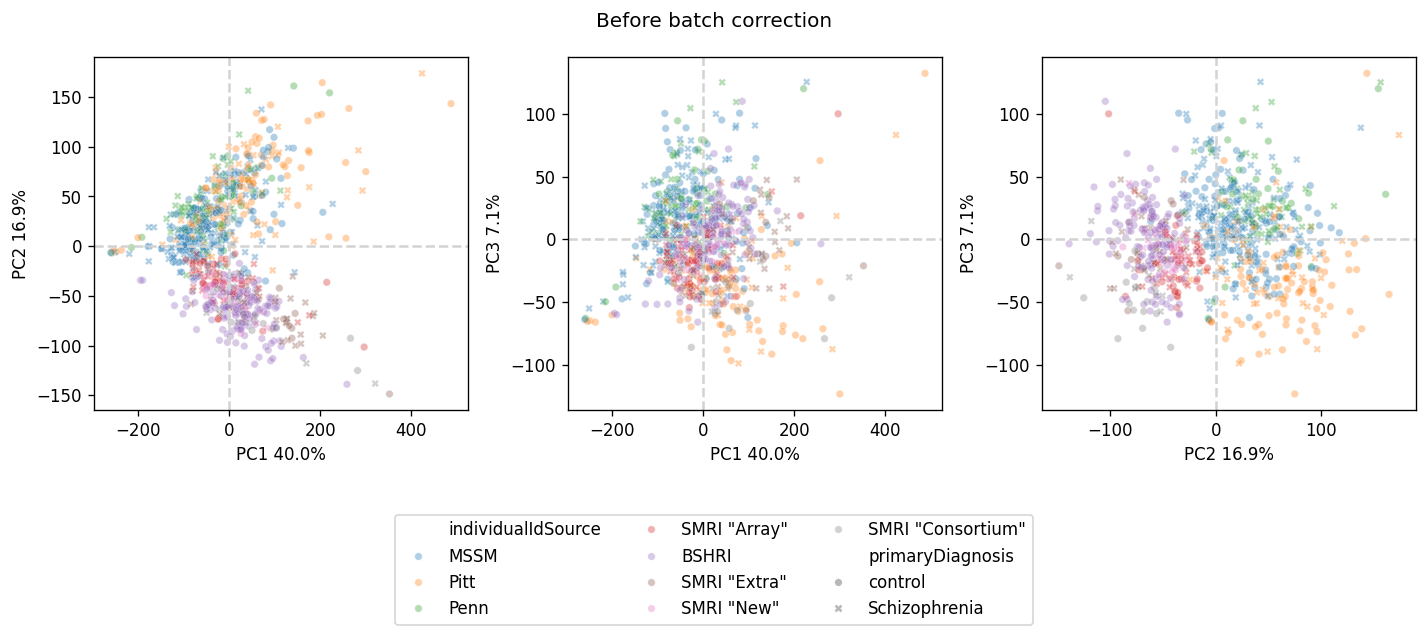

In [8]:
f, axes = plt.subplots(1, 3, figsize=(12,4), dpi = 120)

ax=axes[0]
sns.scatterplot(data=PCA_Filtered, s=20, x=f"PC1", y=f"PC2", 
                     style="primaryDiagnosis",
                     hue='individualIdSource',
                    alpha=0.35,
                    ax=ax)
    
ax.axvline(0,0,300, ls = '--', c = "lightgrey")
ax.axhline(0,0,300, ls = '--', c = "lightgrey")
ax.set_xlabel(f'PC1 {"%.1f" % (variance_filtered[0])}%' ) 
ax.set_ylabel(f'PC2 {"%.1f" % (variance_filtered[1])}%' ) 

ax=axes[1]
sns.scatterplot(data=PCA_Filtered, s=20, x=f"PC1", y=f"PC3", 
                     style="primaryDiagnosis",
                     hue='individualIdSource',
                    alpha=0.35,
                    ax=ax)
    
ax.axvline(0,0,300, ls = '--', c = "lightgrey")
ax.axhline(0,0,300, ls = '--', c = "lightgrey")
ax.set_xlabel(f'PC1 {"%.1f" % (variance_filtered[0])}%' ) 
ax.set_ylabel(f'PC3 {"%.1f" % (variance_filtered[2])}%' ) 

ax=axes[2]
sns.scatterplot(data=PCA_Filtered, s=20, x=f"PC2", y=f"PC3", 
                     style="primaryDiagnosis",
                     hue='individualIdSource',
                    alpha=0.35,
                    ax=ax)
    
ax.axvline(0,0,300, ls = '--', c = "lightgrey")
ax.axhline(0,0,300, ls = '--', c = "lightgrey")
ax.set_xlabel(f'PC2 {"%.1f" % (variance_filtered[1])}%' ) 
ax.set_ylabel(f'PC3 {"%.1f" % (variance_filtered[2])}%' ) 

for ax in axes:
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()

f.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)

plt.suptitle('Before batch correction')

plt.tight_layout()
plt.show()
plt.close()

In [9]:
scaling = StandardScaler()
Scaled_data_ComBatSeq = scaling.fit_transform(PsychENCODE_ComBatSeq)
principal = PCA(n_components=3)
PC_ComBatSeq = principal.fit_transform(Scaled_data_ComBatSeq)
variance_ComBatSeq = principal.explained_variance_ratio_ * 100

pc_dict_ComBatSeq = {'PC1':[],'PC2':[],'PC3':[]}
for line in PC_ComBatSeq:
    pc_dict_ComBatSeq['PC1'].append(line[0])
    pc_dict_ComBatSeq['PC2'].append(line[1])
    pc_dict_ComBatSeq['PC3'].append(line[2])
    
PCA_ComBatSeq = pd.DataFrame.from_dict(pc_dict_ComBatSeq)
PCA_ComBatSeq["individualID"] = PsychENCODE_ComBatSeq.index.tolist()
PCA_ComBatSeq = PCA_ComBatSeq.merge(PsychENCODE_Metadata, on='individualID', how='left')

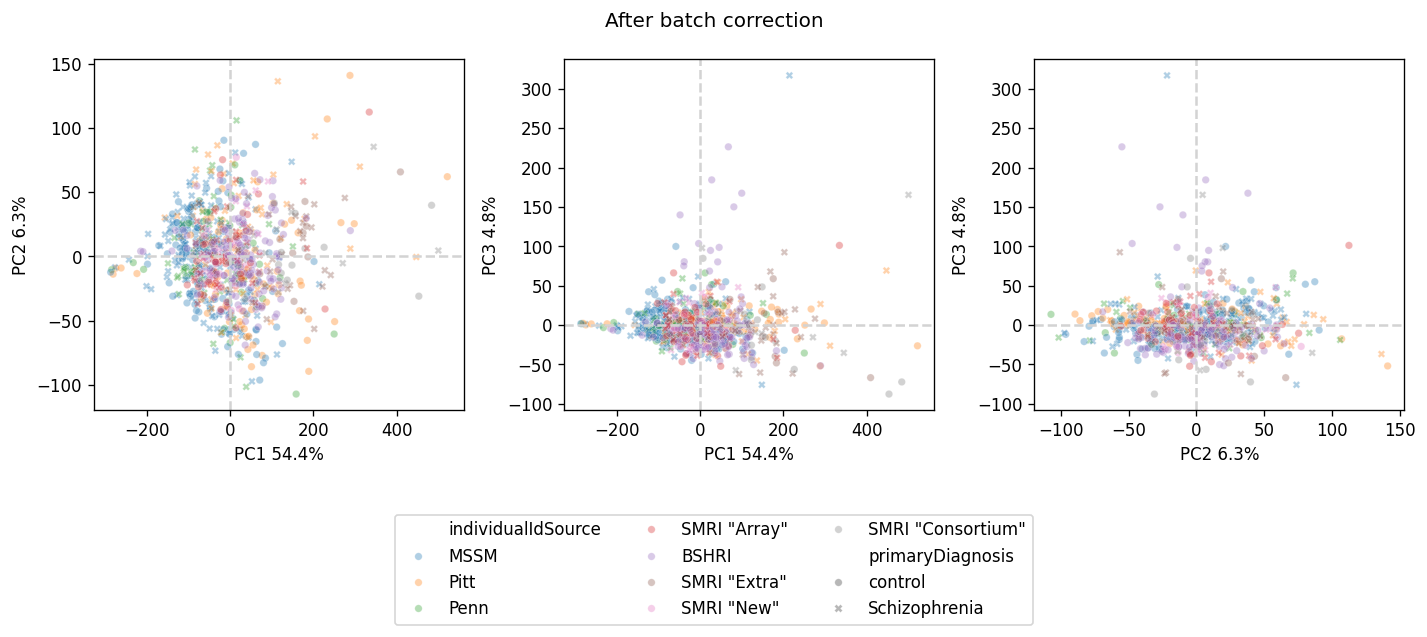

In [10]:
f, axes = plt.subplots(1, 3, figsize=(12,4), dpi = 120)

ax=axes[0]
sns.scatterplot(data=PCA_ComBatSeq, s=20, x=f"PC1", y=f"PC2", 
                     style="primaryDiagnosis",
                     hue='individualIdSource',
                    alpha=0.35,
                    ax=ax)
    
ax.axvline(0,0,300, ls = '--', c = "lightgrey")
ax.axhline(0,0,300, ls = '--', c = "lightgrey")
ax.set_xlabel(f'PC1 {"%.1f" % (variance_ComBatSeq[0])}%' ) 
ax.set_ylabel(f'PC2 {"%.1f" % (variance_ComBatSeq[1])}%' ) 

ax=axes[1]
sns.scatterplot(data=PCA_ComBatSeq, s=20, x=f"PC1", y=f"PC3", 
                     style="primaryDiagnosis",
                     hue='individualIdSource',
                    alpha=0.35,
                    ax=ax)
    
ax.axvline(0,0,300, ls = '--', c = "lightgrey")
ax.axhline(0,0,300, ls = '--', c = "lightgrey")
ax.set_xlabel(f'PC1 {"%.1f" % (variance_ComBatSeq[0])}%' ) 
ax.set_ylabel(f'PC3 {"%.1f" % (variance_ComBatSeq[2])}%' ) 

ax=axes[2]
sns.scatterplot(data=PCA_ComBatSeq, s=20, x=f"PC2", y=f"PC3", 
                     style="primaryDiagnosis",
                     hue='individualIdSource',
                    alpha=0.35,
                    ax=ax)
    
ax.axvline(0,0,300, ls = '--', c = "lightgrey")
ax.axhline(0,0,300, ls = '--', c = "lightgrey")
ax.set_xlabel(f'PC2 {"%.1f" % (variance_ComBatSeq[1])}%' ) 
ax.set_ylabel(f'PC3 {"%.1f" % (variance_ComBatSeq[2])}%' ) 

for ax in axes:
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()

f.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)

plt.suptitle('After batch correction')

plt.tight_layout()
plt.show()
plt.close()

# pyDeSeq2

In [11]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [12]:
PsychENCODE_Metadata['age_cohort'] = np.nan
PsychENCODE_Metadata.loc[PsychENCODE_Metadata.ageDeath < 50, 'age_cohort'] = 'young'
PsychENCODE_Metadata.loc[PsychENCODE_Metadata.ageDeath >= 50, 'age_cohort'] = 'old'

In [13]:
inference = DefaultInference(n_cpus=16)
dds = DeseqDataSet(
    counts=PsychENCODE_ComBatSeq,
    metadata=PsychENCODE_Metadata,
    design_factors=['primaryDiagnosis', 'age_cohort'],
    refit_cooks=True,
    inference=inference,
)

/tmp/ipykernel_935197/2657619278.py:2: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(


In [14]:
dds.deseq2()

Fitting size factors...
... done in 0.62 seconds.

Fitting dispersions...
... done in 6.87 seconds.

Fitting dispersion trend curve...
... done in 1.03 seconds.

Fitting MAP dispersions...
... done in 7.94 seconds.

Fitting LFCs...
... done in 7.46 seconds.

Refitting 165 outliers.

Fitting dispersions...
... done in 0.20 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.23 seconds.



In [15]:
dds.vst()

Fitting dispersions...
... done in 6.15 seconds.

Fitting dispersion trend curve...
... done in 1.24 seconds.



In [16]:
Deseq_counts = pd.DataFrame(dds.layers['normed_counts'], 
                            index = PsychENCODE_ComBatSeq.index, 
                            columns = PsychENCODE_ComBatSeq.columns)

In [17]:
Deseq_counts.to_csv('../data/PsychENCODE-pyDeSeq2.csv')

In [18]:
Deseq_vst = pd.DataFrame(dds.layers['vst_counts'], 
                         index = PsychENCODE_ComBatSeq.index, 
                         columns = PsychENCODE_ComBatSeq.columns)

In [19]:
Deseq_vst.to_csv('../data/PsychENCODE-pyDeSeq2.VST.csv')

In [20]:
stat_diagnosis = DeseqStats(dds, contrast=["primaryDiagnosis", "Schizophrenia", "control"], inference=inference)
stat_diagnosis.summary()

stat_age = DeseqStats(dds, contrast=['age-cohort', "old", "young"], inference=inference)
stat_age.summary()

Running Wald tests...
... done in 5.37 seconds.



Log2 fold change & Wald test p-value: primaryDiagnosis Schizophrenia vs control
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000000003  153.686532       -0.006191  0.024649 -0.251189  0.801668   
ENSG00000000419  407.276925       -0.091805  0.028418 -3.230579  0.001235   
ENSG00000000457  278.502644        0.016585  0.014965  1.108258  0.267750   
ENSG00000000460  105.638885        0.000528  0.026405  0.020002  0.984042   
ENSG00000000938   47.090115        0.046799  0.053466  0.875296  0.381413   
...                     ...             ...       ...       ...       ...   
ENSGR0000182484   91.862438        0.044520  0.031707  1.404093  0.160291   
ENSGR0000197976  154.921678       -0.006392  0.021163 -0.302021  0.762636   
ENSGR0000198223   35.800266       -0.168847  0.051833 -3.257511  0.001124   
ENSGR0000214717  251.077908       -0.011080  0.021662 -0.511510  0.608994   
ENSGR0000236017   12.757333        0.002432  0.055979  0.043446  0.965346

Running Wald tests...
... done in 5.44 seconds.



Log2 fold change & Wald test p-value: age-cohort old vs young
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000000003  153.686532        0.054830  0.027175  2.017625  0.043630   
ENSG00000000419  407.276925       -0.067207  0.031421 -2.138902  0.032444   
ENSG00000000457  278.502644        0.041109  0.016459  2.497668  0.012501   
ENSG00000000460  105.638885        0.071078  0.029087  2.443651  0.014539   
ENSG00000000938   47.090115       -0.042076  0.058980 -0.713399  0.475599   
...                     ...             ...       ...       ...       ...   
ENSGR0000182484   91.862438       -0.014172  0.034925 -0.405773  0.684910   
ENSGR0000197976  154.921678       -0.013889  0.023260 -0.597126  0.550423   
ENSGR0000198223   35.800266       -0.202585  0.056874 -3.562020  0.000368   
ENSGR0000214717  251.077908       -0.012583  0.023884 -0.526825  0.598315   
ENSGR0000236017   12.757333       -0.011319  0.061213 -0.184910  0.853299   

             

In [21]:
result_Age = stat_age.results_df
result_Diagnosis = stat_diagnosis.results_df

In [22]:
DeseqResult = pd.concat([result_Diagnosis.add_suffix('_Diagnosis'), result_Age.add_suffix('_Age')], axis=1)
DeseqResult

,baseMean_Diagnosis,log2FoldChange_Diagnosis,lfcSE_Diagnosis,stat_Diagnosis,pvalue_Diagnosis,padj_Diagnosis,baseMean_Age,log2FoldChange_Age,lfcSE_Age,stat_Age,pvalue_Age,padj_Age
ENSG00000000003,153.686532,-0.006191,0.024649,-0.251189,0.801668,0.855169,153.686532,0.054830,0.027175,2.017625,0.043630,0.103223
ENSG00000000419,407.276925,-0.091805,0.028418,-3.230579,0.001235,0.004490,407.276925,-0.067207,0.031421,-2.138902,0.032444,0.082553
ENSG00000000457,278.502644,0.016585,0.014965,1.108258,0.267750,0.371458,278.502644,0.041109,0.016459,2.497668,0.012501,0.040167
ENSG00000000460,105.638885,0.000528,0.026405,0.020002,0.984042,0.988922,105.638885,0.071078,0.029087,2.443651,0.014539,0.045077
ENSG00000000938,47.090115,0.046799,0.053466,0.875296,0.381413,0.489641,47.090115,-0.042076,0.058980,-0.713399,0.475599,0.610644
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSGR0000182484,91.862438,0.044520,0.031707,1.404093,0.160291,0.247087,91.862438,-0.014172,0.034925,-0.405773,0.684910,0.782771
ENSGR0000197976,154.921678,-0.006392,0.021163,-0.302021,0.762636,0.824547,154.921678,-0.013889,0.023260,-0.597126,0.550423,0.675674
ENSGR0000198223,35.800266,-0.168847,0.051833,-3.257511,0.001124,0.004161,35.800266,-0.202585,0.056874,-3.562020,0.000368,0.002908
ENSGR0000214717,251.077908,-0.011080,0.021662,-0.511510,0.608994,0.696428,251.077908,-0.012583,0.023884,-0.526825,0.598315,0.714762


In [23]:
DeseqResult.to_csv('results/LFC.Diagnosis&Age.csv')

In [24]:
statistics_deseq_significant = DeseqResult.query('padj_Diagnosis < 0.05 & padj_Age < 0.05')
statistics_deseq_significant = statistics_deseq_significant.loc[np.abs(statistics_deseq_significant.log2FoldChange_Diagnosis) > np.log2(1.1) , :]
statistics_deseq_significant = statistics_deseq_significant.loc[np.abs(statistics_deseq_significant.log2FoldChange_Age) > np.log2(1.1) , :]

In [25]:
Sq1 = np.quantile(statistics_deseq_significant.log2FoldChange_Diagnosis, 0.1)
Sq2 = np.quantile(statistics_deseq_significant.log2FoldChange_Diagnosis, 0.2)
Sq3 = np.quantile(statistics_deseq_significant.log2FoldChange_Diagnosis, 0.3)
Sq4 = np.quantile(statistics_deseq_significant.log2FoldChange_Diagnosis, 0.4)
Sq5 = np.quantile(statistics_deseq_significant.log2FoldChange_Diagnosis, 0.5)
Sq6 = np.quantile(statistics_deseq_significant.log2FoldChange_Diagnosis, 0.6)
Sq7 = np.quantile(statistics_deseq_significant.log2FoldChange_Diagnosis, 0.7)
Sq8 = np.quantile(statistics_deseq_significant.log2FoldChange_Diagnosis, 0.8)
Sq9 = np.quantile(statistics_deseq_significant.log2FoldChange_Diagnosis, 0.9)

Aq1 = np.quantile(statistics_deseq_significant.log2FoldChange_Age, 0.1)
Aq2 = np.quantile(statistics_deseq_significant.log2FoldChange_Age, 0.2)
Aq3 = np.quantile(statistics_deseq_significant.log2FoldChange_Age, 0.3)
Aq4 = np.quantile(statistics_deseq_significant.log2FoldChange_Age, 0.4)
Aq5 = np.quantile(statistics_deseq_significant.log2FoldChange_Age, 0.5)
Aq6 = np.quantile(statistics_deseq_significant.log2FoldChange_Age, 0.6)
Aq7 = np.quantile(statistics_deseq_significant.log2FoldChange_Age, 0.7)
Aq8 = np.quantile(statistics_deseq_significant.log2FoldChange_Age, 0.8)
Aq9 = np.quantile(statistics_deseq_significant.log2FoldChange_Age, 0.9)

status_column = 'log2(Schizophrenia/Control) quantiles'
statistics_deseq_significant[status_column] = np.nan

statistics_deseq_significant.loc[statistics_deseq_significant.log2FoldChange_Diagnosis  <= Sq1, status_column] = 'Q1'
statistics_deseq_significant.loc[(Sq1 < statistics_deseq_significant.log2FoldChange_Diagnosis) & (statistics_deseq_significant.log2FoldChange_Diagnosis  <= Sq2), status_column] = 'Q2'
statistics_deseq_significant.loc[(Sq2 < statistics_deseq_significant.log2FoldChange_Diagnosis) & (statistics_deseq_significant.log2FoldChange_Diagnosis  <= Sq3), status_column] = 'Q3'
statistics_deseq_significant.loc[(Sq3 < statistics_deseq_significant.log2FoldChange_Diagnosis) & (statistics_deseq_significant.log2FoldChange_Diagnosis  <= Sq4), status_column] = 'Q4'
statistics_deseq_significant.loc[(Sq4 < statistics_deseq_significant.log2FoldChange_Diagnosis) & (statistics_deseq_significant.log2FoldChange_Diagnosis  <= Sq5), status_column] = 'Q5'
statistics_deseq_significant.loc[(Sq5 < statistics_deseq_significant.log2FoldChange_Diagnosis) & (statistics_deseq_significant.log2FoldChange_Diagnosis  <= Sq6), status_column] = 'Q6'
statistics_deseq_significant.loc[(Sq6 < statistics_deseq_significant.log2FoldChange_Diagnosis) & (statistics_deseq_significant.log2FoldChange_Diagnosis  <= Sq7), status_column] = 'Q7'
statistics_deseq_significant.loc[(Sq7 < statistics_deseq_significant.log2FoldChange_Diagnosis) & (statistics_deseq_significant.log2FoldChange_Diagnosis  <= Sq8), status_column] = 'Q8'
statistics_deseq_significant.loc[(Sq8 < statistics_deseq_significant.log2FoldChange_Diagnosis) & (statistics_deseq_significant.log2FoldChange_Diagnosis  <= Sq9), status_column] = 'Q9'
statistics_deseq_significant.loc[(Sq9 < statistics_deseq_significant.log2FoldChange_Diagnosis), status_column] = 'Q10'

age_column = 'log2(Old/Young) quantiles'
statistics_deseq_significant[age_column] = np.nan
statistics_deseq_significant.loc[statistics_deseq_significant.log2FoldChange_Age <= Aq1, age_column] = 'Q1'
statistics_deseq_significant.loc[(Aq1 < statistics_deseq_significant.log2FoldChange_Age) & (statistics_deseq_significant.log2FoldChange_Age <= Aq2), age_column] = 'Q2'
statistics_deseq_significant.loc[(Aq2 < statistics_deseq_significant.log2FoldChange_Age) & (statistics_deseq_significant.log2FoldChange_Age <= Aq3), age_column] = 'Q3'
statistics_deseq_significant.loc[(Aq3 < statistics_deseq_significant.log2FoldChange_Age) & (statistics_deseq_significant.log2FoldChange_Age <= Aq4), age_column] = 'Q4'
statistics_deseq_significant.loc[(Aq4 < statistics_deseq_significant.log2FoldChange_Age) & (statistics_deseq_significant.log2FoldChange_Age <= Aq5), age_column] = 'Q5'
statistics_deseq_significant.loc[(Aq5 < statistics_deseq_significant.log2FoldChange_Age) & (statistics_deseq_significant.log2FoldChange_Age <= Aq6), age_column] = 'Q6'
statistics_deseq_significant.loc[(Aq6 < statistics_deseq_significant.log2FoldChange_Age) & (statistics_deseq_significant.log2FoldChange_Age <= Aq7), age_column] = 'Q7'
statistics_deseq_significant.loc[(Aq7 < statistics_deseq_significant.log2FoldChange_Age) & (statistics_deseq_significant.log2FoldChange_Age <= Aq8), age_column] = 'Q8'
statistics_deseq_significant.loc[(Aq8 < statistics_deseq_significant.log2FoldChange_Age) & (statistics_deseq_significant.log2FoldChange_Age <= Aq9), age_column] = 'Q9'
statistics_deseq_significant.loc[(Aq9 < statistics_deseq_significant.log2FoldChange_Age), age_column] = 'Q10'

In [26]:
statistics_deseq_significant.to_csv('results/LFC.Schizophrenia&Age.quantiles.csv')

In [27]:
cross_df = pd.crosstab(statistics_deseq_significant[status_column], statistics_deseq_significant[age_column])
cross_df = cross_df.loc[['Q1','Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9','Q10'][::-1], ['Q1','Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9','Q10']]
cross_df.to_csv('results/Crosstable.csv')

In [28]:
log2FoldChange_Age = statistics_deseq_significant.log2FoldChange_Age.sort_values()
log2FoldChange_Diagnosis = statistics_deseq_significant.log2FoldChange_Diagnosis.sort_values()

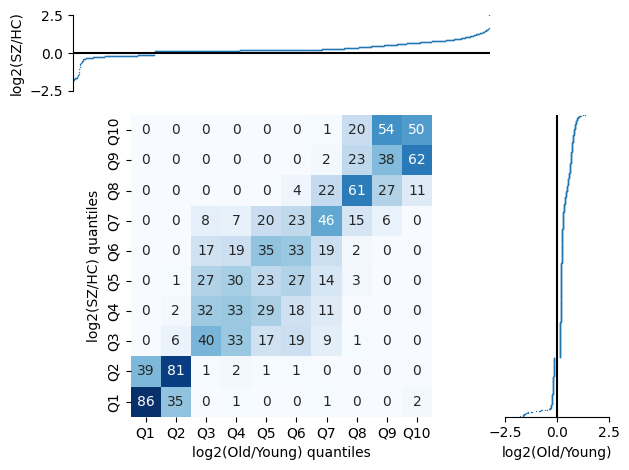

In [29]:
f, axs = plt.subplots(2,2, width_ratios=(4,1), height_ratios=(1, 4),)

ax = axs[0,0]
sns.scatterplot(y=log2FoldChange_Age, x=np.arange(len(log2FoldChange_Age)), edgecolors=None, s=0.75, ax=ax)
ax.set_ylabel('log2(SZ/HC)')
ax.axhline(y=0, color='k', linestyle='-')
ax.margins(x=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_ylim([-2.5,2.5])
ax.set_xticks([])

ax = axs[1,0]
sns.heatmap(cross_df, annot=True, fmt="d", cmap='Blues', cbar=None,square=True, ax=ax)
ax.set_ylabel('log2(SZ/HC) quantiles')

ax = axs[0,1]
ax.set_axis_off()

ax = axs[1,1]
sns.scatterplot(x=log2FoldChange_Diagnosis, y=np.arange(len(log2FoldChange_Diagnosis)), edgecolors=None, s=0.75)
ax.axvline(x=0, color='k', linestyle='-')
ax.set_xlim([-2.5,2.5])
ax.set_yticks([])
ax.set_xlabel('log2(Old/Young)')
ax.margins(y=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()

plt.show()
plt.close()